# Washington, D.C. Bikeshare Demand Analysis

## 1. Title + Overview

This project analyzes Washington, D.C. bikeshare usage to understand how ridership changes across time, weather, and rider type, and to test how well hourly demand can be predicted. It combines exploratory analysis with practical forecasting so the results are useful both for explanation and for operational planning.


## 2. Business / Analytical Question

This case study answers two related questions:

- How does bikeshare ridership vary by time, weather, and rider type?
- Can hourly demand be predicted well enough to support planning decisions?

This matters because operators and planners need to anticipate peaks, prepare for weather-driven swings, and understand whether commuter and leisure riders behave differently enough to require different planning assumptions.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.append(str(ROOT / "src"))

from bikeshare_analysis import FIGURE_DIR, build_daily_summary, generate_project_outputs

outputs = generate_project_outputs()
bike = outputs["cleaned_df"]
quality = outputs["quality_df"]
features = outputs["feature_df"]
stats_df = outputs["stats_df"]
metrics = outputs["metrics_df"]
importance = outputs["importance_df"]
coefficients = outputs["coefficient_df"]

## 3. Dataset Overview

The analysis uses the Capital Bikeshare hourly ridership dataset covering **January 1, 2011 through December 31, 2012**. The unit of observation is a single **hour**, with each row capturing weather, calendar context, and rider counts for that hour.

Key variables include:

- `cnt`: total hourly rides
- `casual`: hourly casual rides
- `registered`: hourly registered rides
- `hr`, `weekday`, `mnth`, `season`: time context
- `temp`, `atemp`, `hum`, `windspeed`, `weathersit`: weather conditions


In [2]:
dataset_summary = pd.DataFrame(
    {
        "metric": ["Rows", "Columns", "Date range", "Granularity"],
        "value": [
            f"{bike.shape[0]:,}",
            bike.shape[1],
            f"{bike['dteday'].min().date()} to {bike['dteday'].max().date()}",
            "Hourly",
        ],
    }
)
display(dataset_summary)
display(bike[['dteday', 'hr', 'season_label', 'weather_label', 'temp_c', 'casual', 'registered', 'cnt']].head())

,metric,value
0,Rows,"17,379"
1,Columns,41
2,Date range,2011-01-01 to 2012-12-31
3,Granularity,Hourly


,dteday,hr,season_label,weather_label,temp_c,casual,registered,cnt
0,2011-01-01,0,Winter,Clear / Few clouds,9.84,3,13,16
1,2011-01-01,1,Winter,Clear / Few clouds,9.02,8,32,40
2,2011-01-01,2,Winter,Clear / Few clouds,9.02,5,27,32
3,2011-01-01,3,Winter,Clear / Few clouds,9.84,3,10,13
4,2011-01-01,4,Winter,Clear / Few clouds,9.84,0,1,1


## 4. Data Cleaning & Preparation

The source data is relatively clean, but I made a few explicit preparation steps so the analysis is reproducible and readable:

- converted `dteday` to a datetime field and sorted the data chronologically
- verified that `cnt = casual + registered` for every row
- checked for missing values and duplicate rows
- mapped encoded categories such as season, weekday, and weather into readable labels
- converted scaled weather fields into more interpretable units such as Celsius and percentage humidity

No rows were dropped for missing values because the dataset contains no nulls. The main assumption is that the published hourly file is the authoritative record for demand during this period.


In [3]:
quality

,check,result,interpretation
0,Rows,17379,Hourly observations across 2011-2012
1,Date range,2011-01-01 to 2012-12-31,Two full calendar years
2,Missing values,0,No null values detected
3,Duplicate rows,0,No exact duplicates detected
4,Target consistency,True,Total ridership equals casual + registered in ...
5,Distinct days,731,Expected 731 days in range
6,Hours observed,697-730 rows per hour,A small number of timestamps are absent in the...


## 5. Exploratory Data Analysis (EDA)

The exploratory analysis is organized around the main drivers of demand: overall ridership volume, time patterns, rider-segment differences, and weather effects.


### a. Target Variable Overview

Hourly ridership is unevenly distributed, with many moderate-demand hours and a smaller number of sharp demand peaks. Registered riders also account for most rides on a typical hour, which hints at a commute-heavy system.


,mean,median,std,min,max
cnt,189.46,142.0,181.39,1.0,977.0
casual,35.68,17.0,49.31,0.0,367.0
registered,153.79,115.0,151.36,0.0,886.0


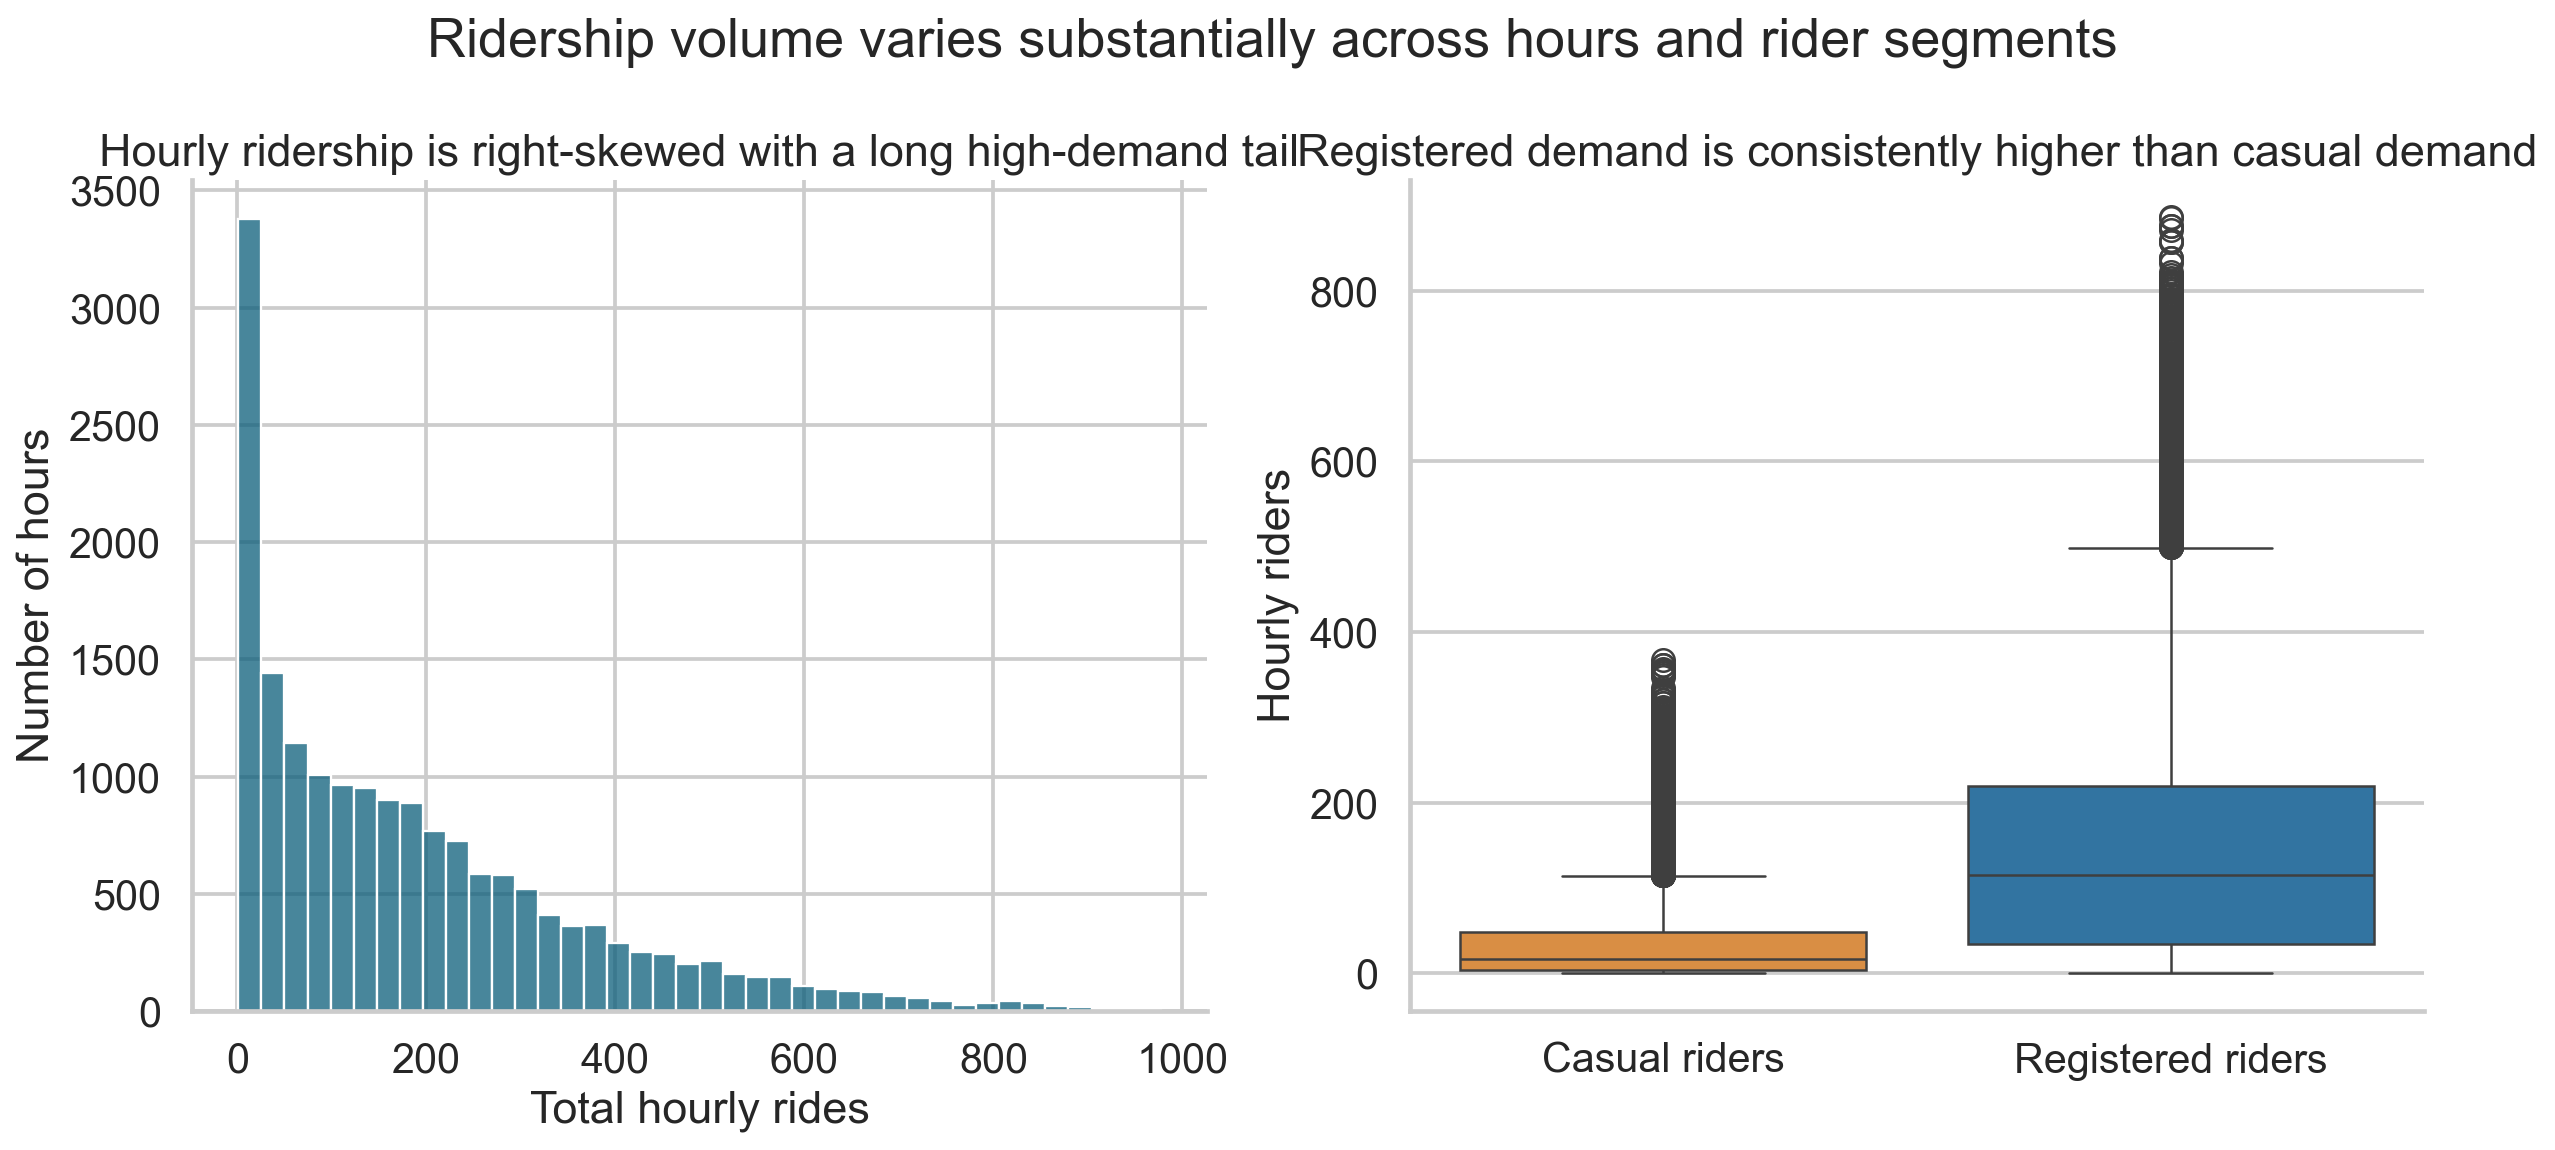

In [4]:
target_summary = bike[['cnt', 'casual', 'registered']].describe().T[['mean', '50%', 'std', 'min', 'max']].rename(
    columns={'50%': 'median'}
).round(2)
display(target_summary)
display(Image(filename=str(FIGURE_DIR / "02_target_distribution.png")))

### b. Time-Based Patterns

Demand changes meaningfully by hour, weekday structure, and seasonality. The plots below show both long-run growth and the strong intraday patterns that define bikeshare usage.


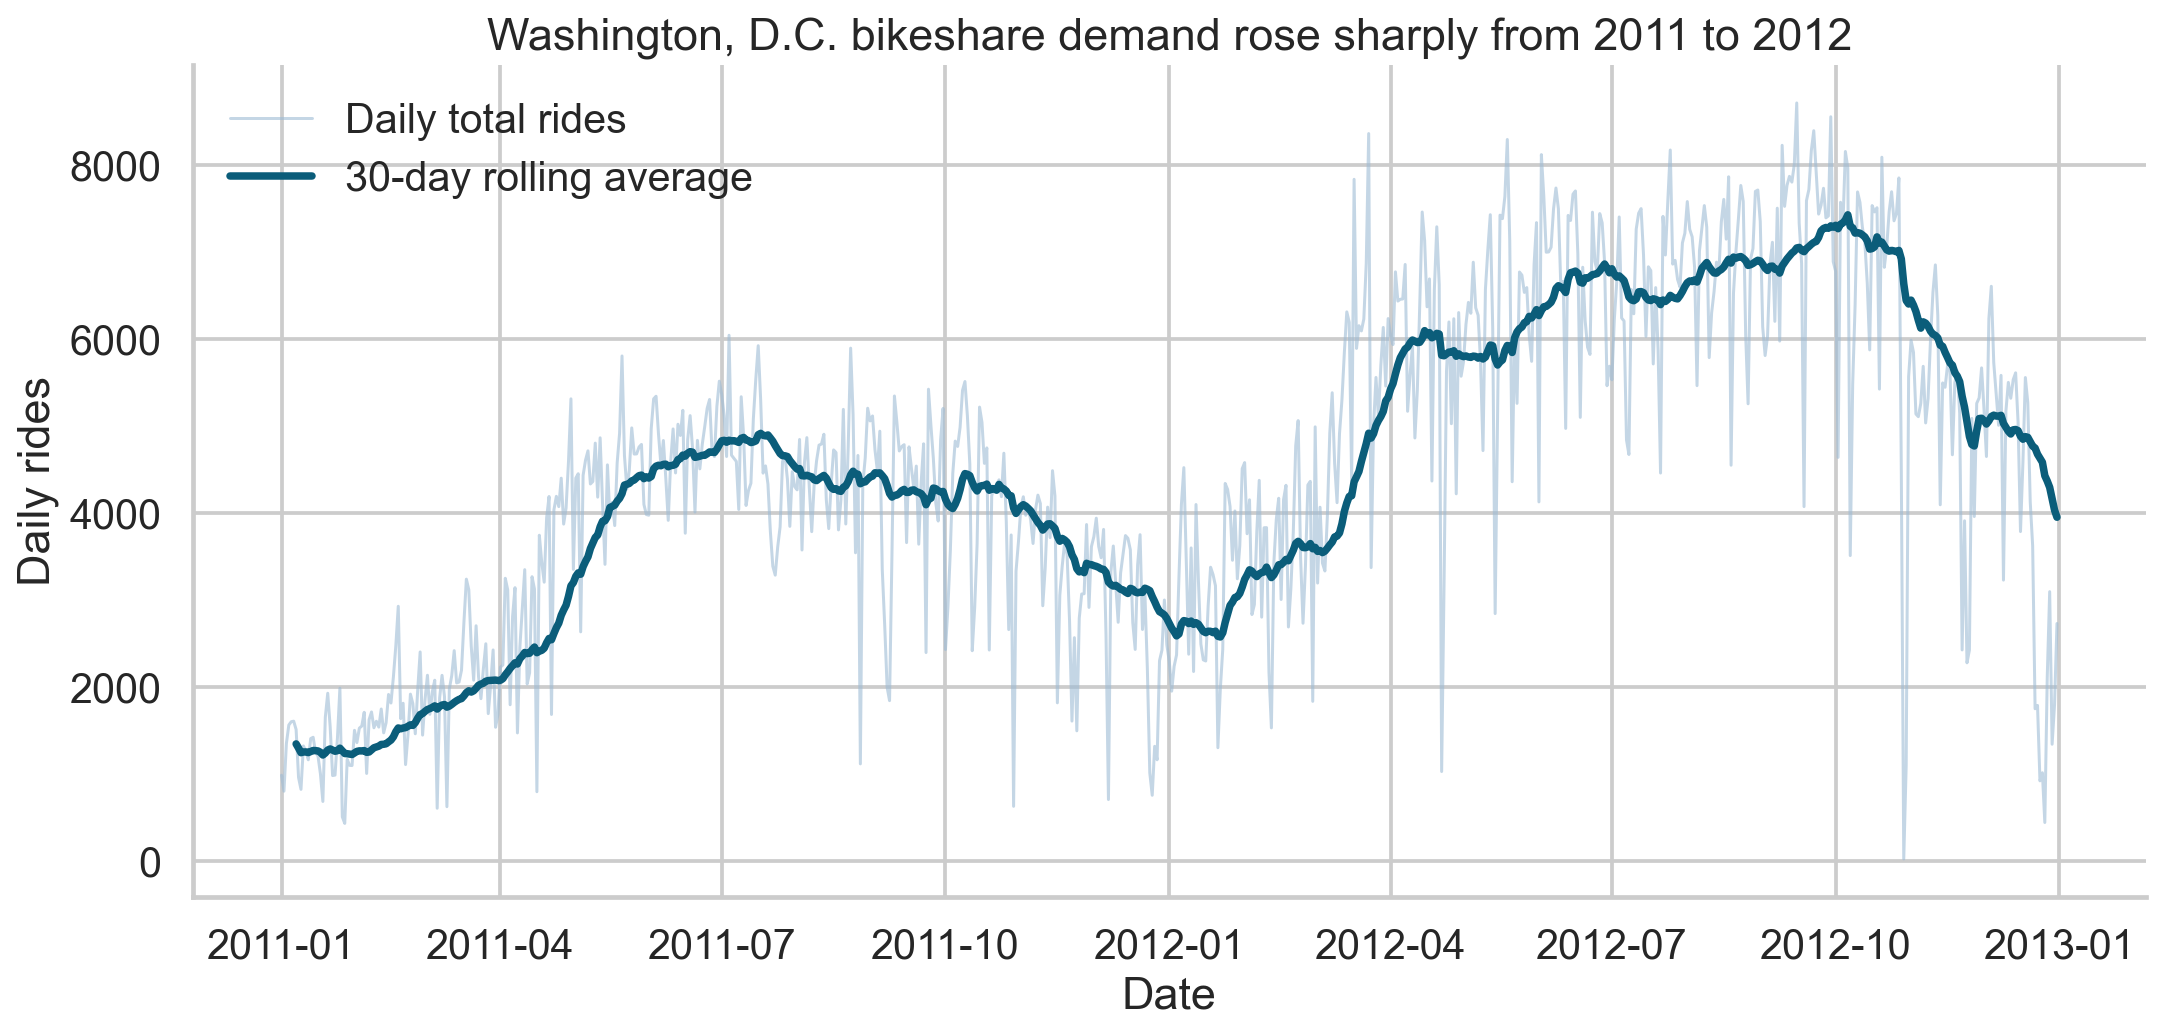

In [5]:
display(Image(filename=str(FIGURE_DIR / "01_daily_demand_trend.png")))

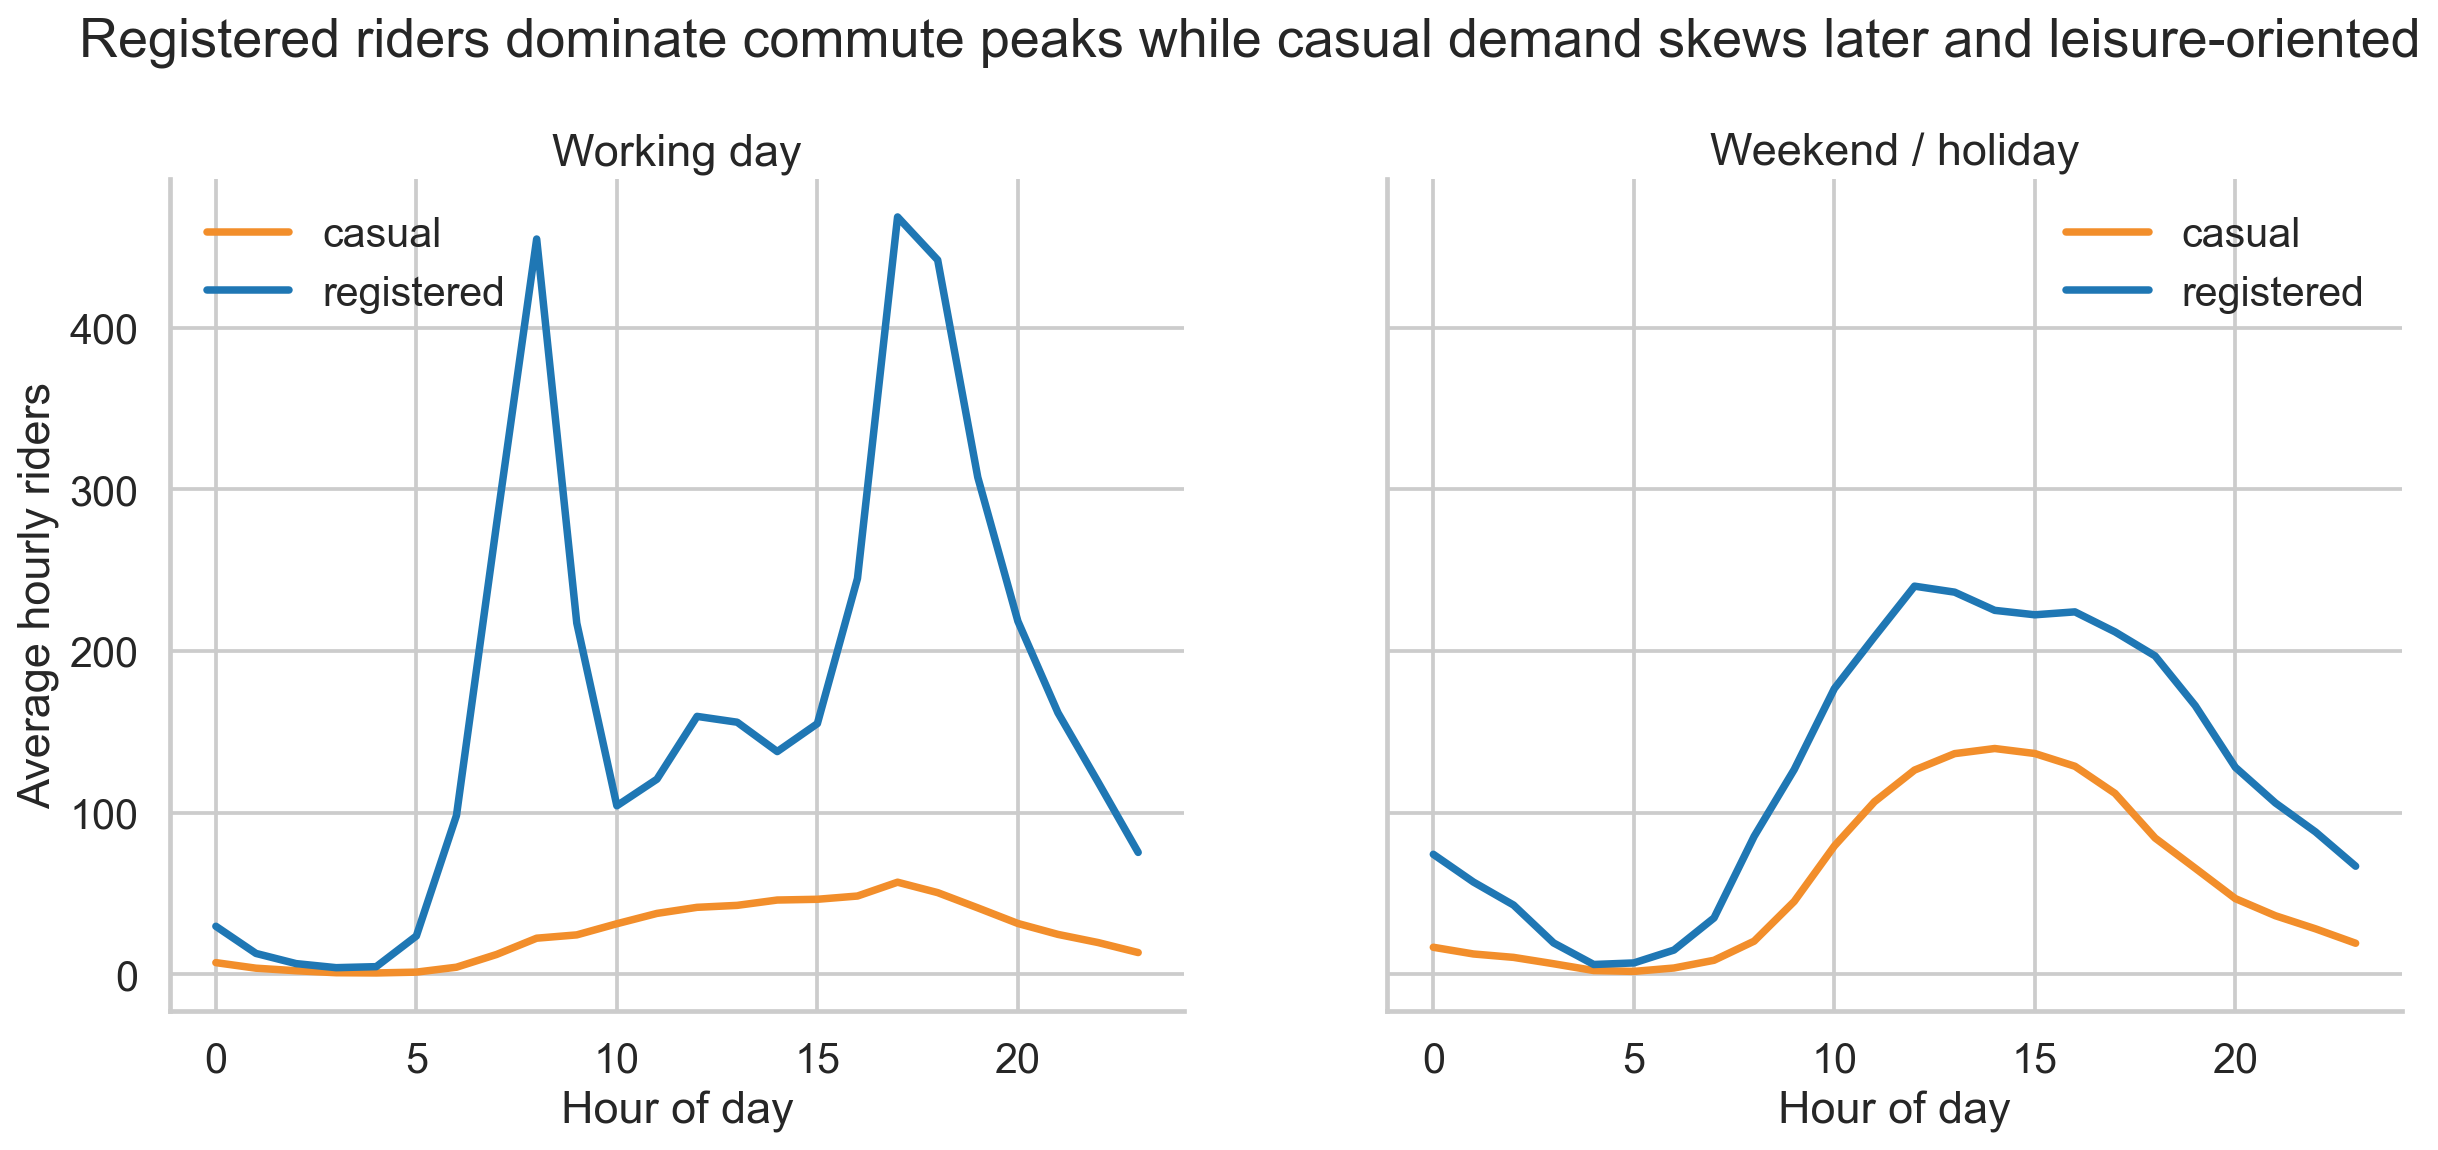

In [6]:
display(Image(filename=str(FIGURE_DIR / "03_hourly_rider_profiles.png")))

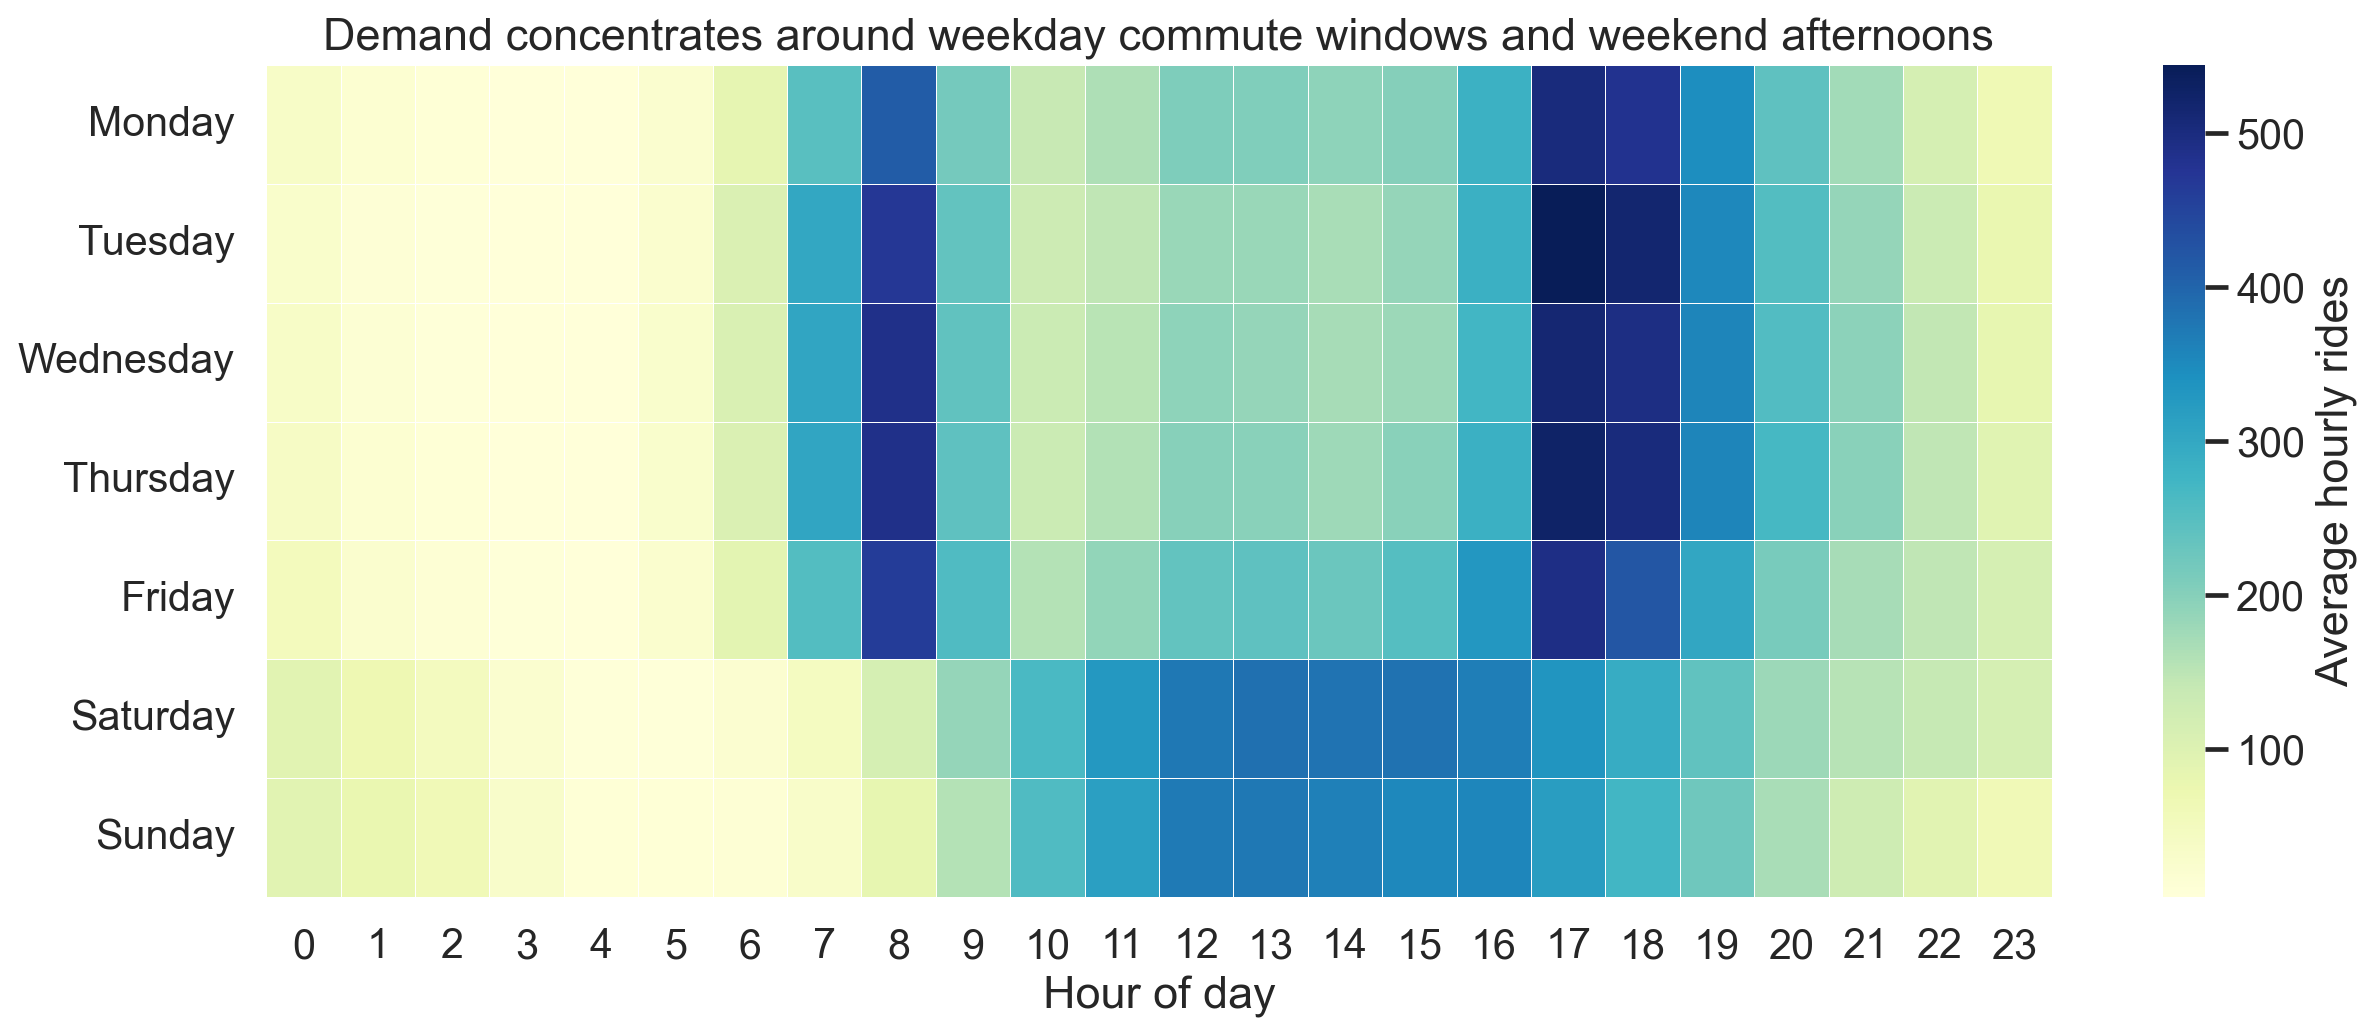

In [7]:
display(Image(filename=str(FIGURE_DIR / "04_weekday_hour_heatmap.png")))

### c. Rider Type Differences

Casual and registered riders do not behave like a single population. Registered riders show much sharper commute peaks, while casual riders are more leisure-oriented and shift toward warmer, non-working days.


In [8]:
rider_type_summary = pd.DataFrame(
    {
        "metric": ["Average hourly casual rides", "Average hourly registered rides", "Average casual share of rides"],
        "value": [
            round(bike['casual'].mean(), 1),
            round(bike['registered'].mean(), 1),
            f"{bike['casual_share'].mean():.1%}",
        ],
    }
)
rider_type_summary

,metric,value
0,Average hourly casual rides,35.7
1,Average hourly registered rides,153.8
2,Average casual share of rides,17.2%


### d. Weather Effects

Weather changes both total demand and rider mix. Temperature tends to lift demand, while precipitation suppresses it, especially for discretionary riding.


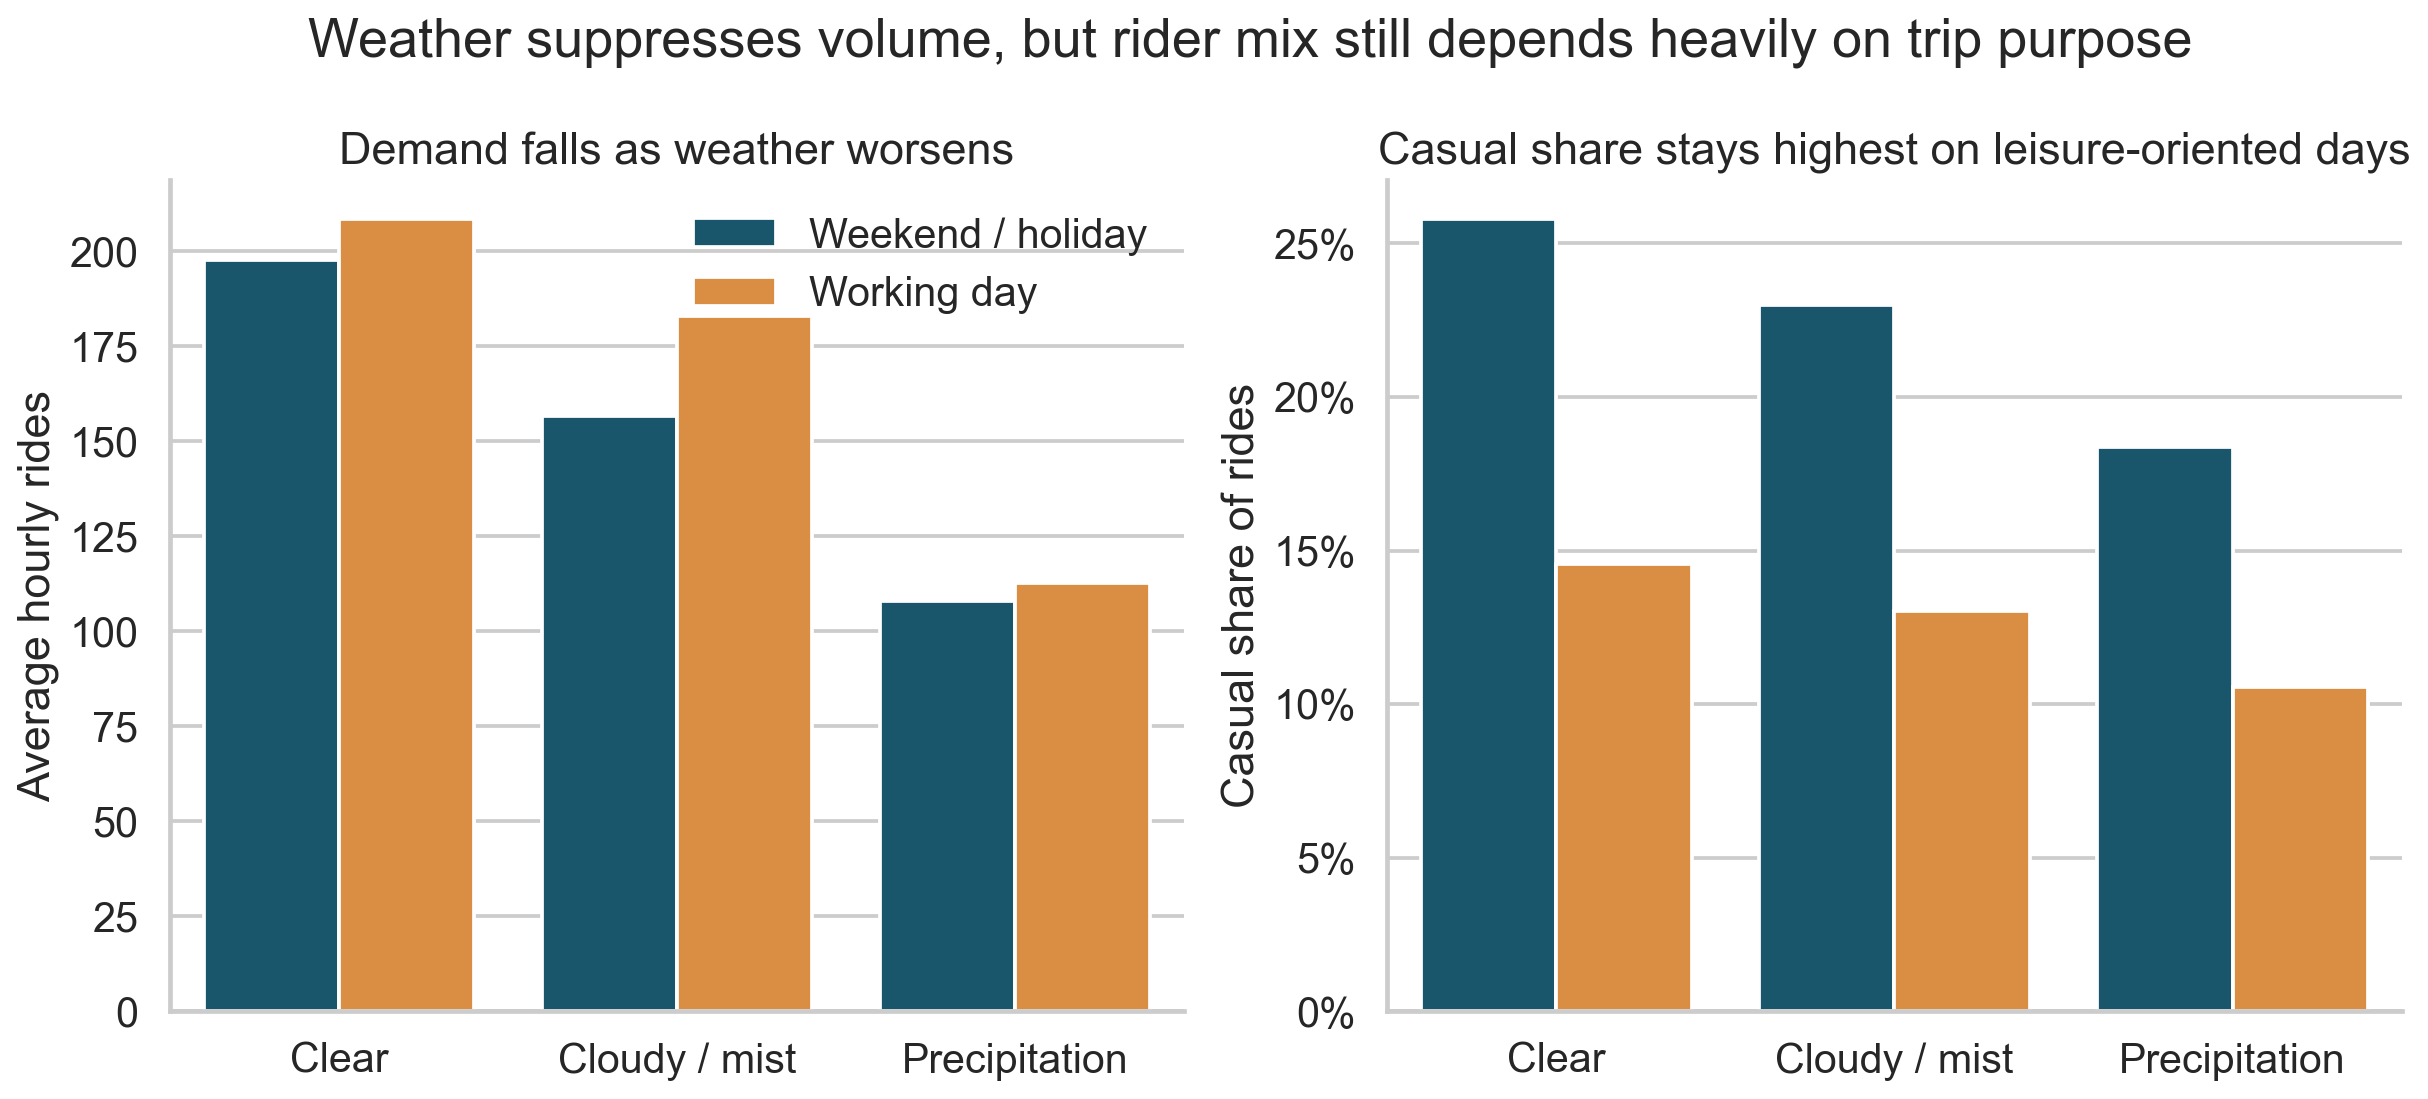

In [9]:
display(Image(filename=str(FIGURE_DIR / "05_weather_impact.png")))

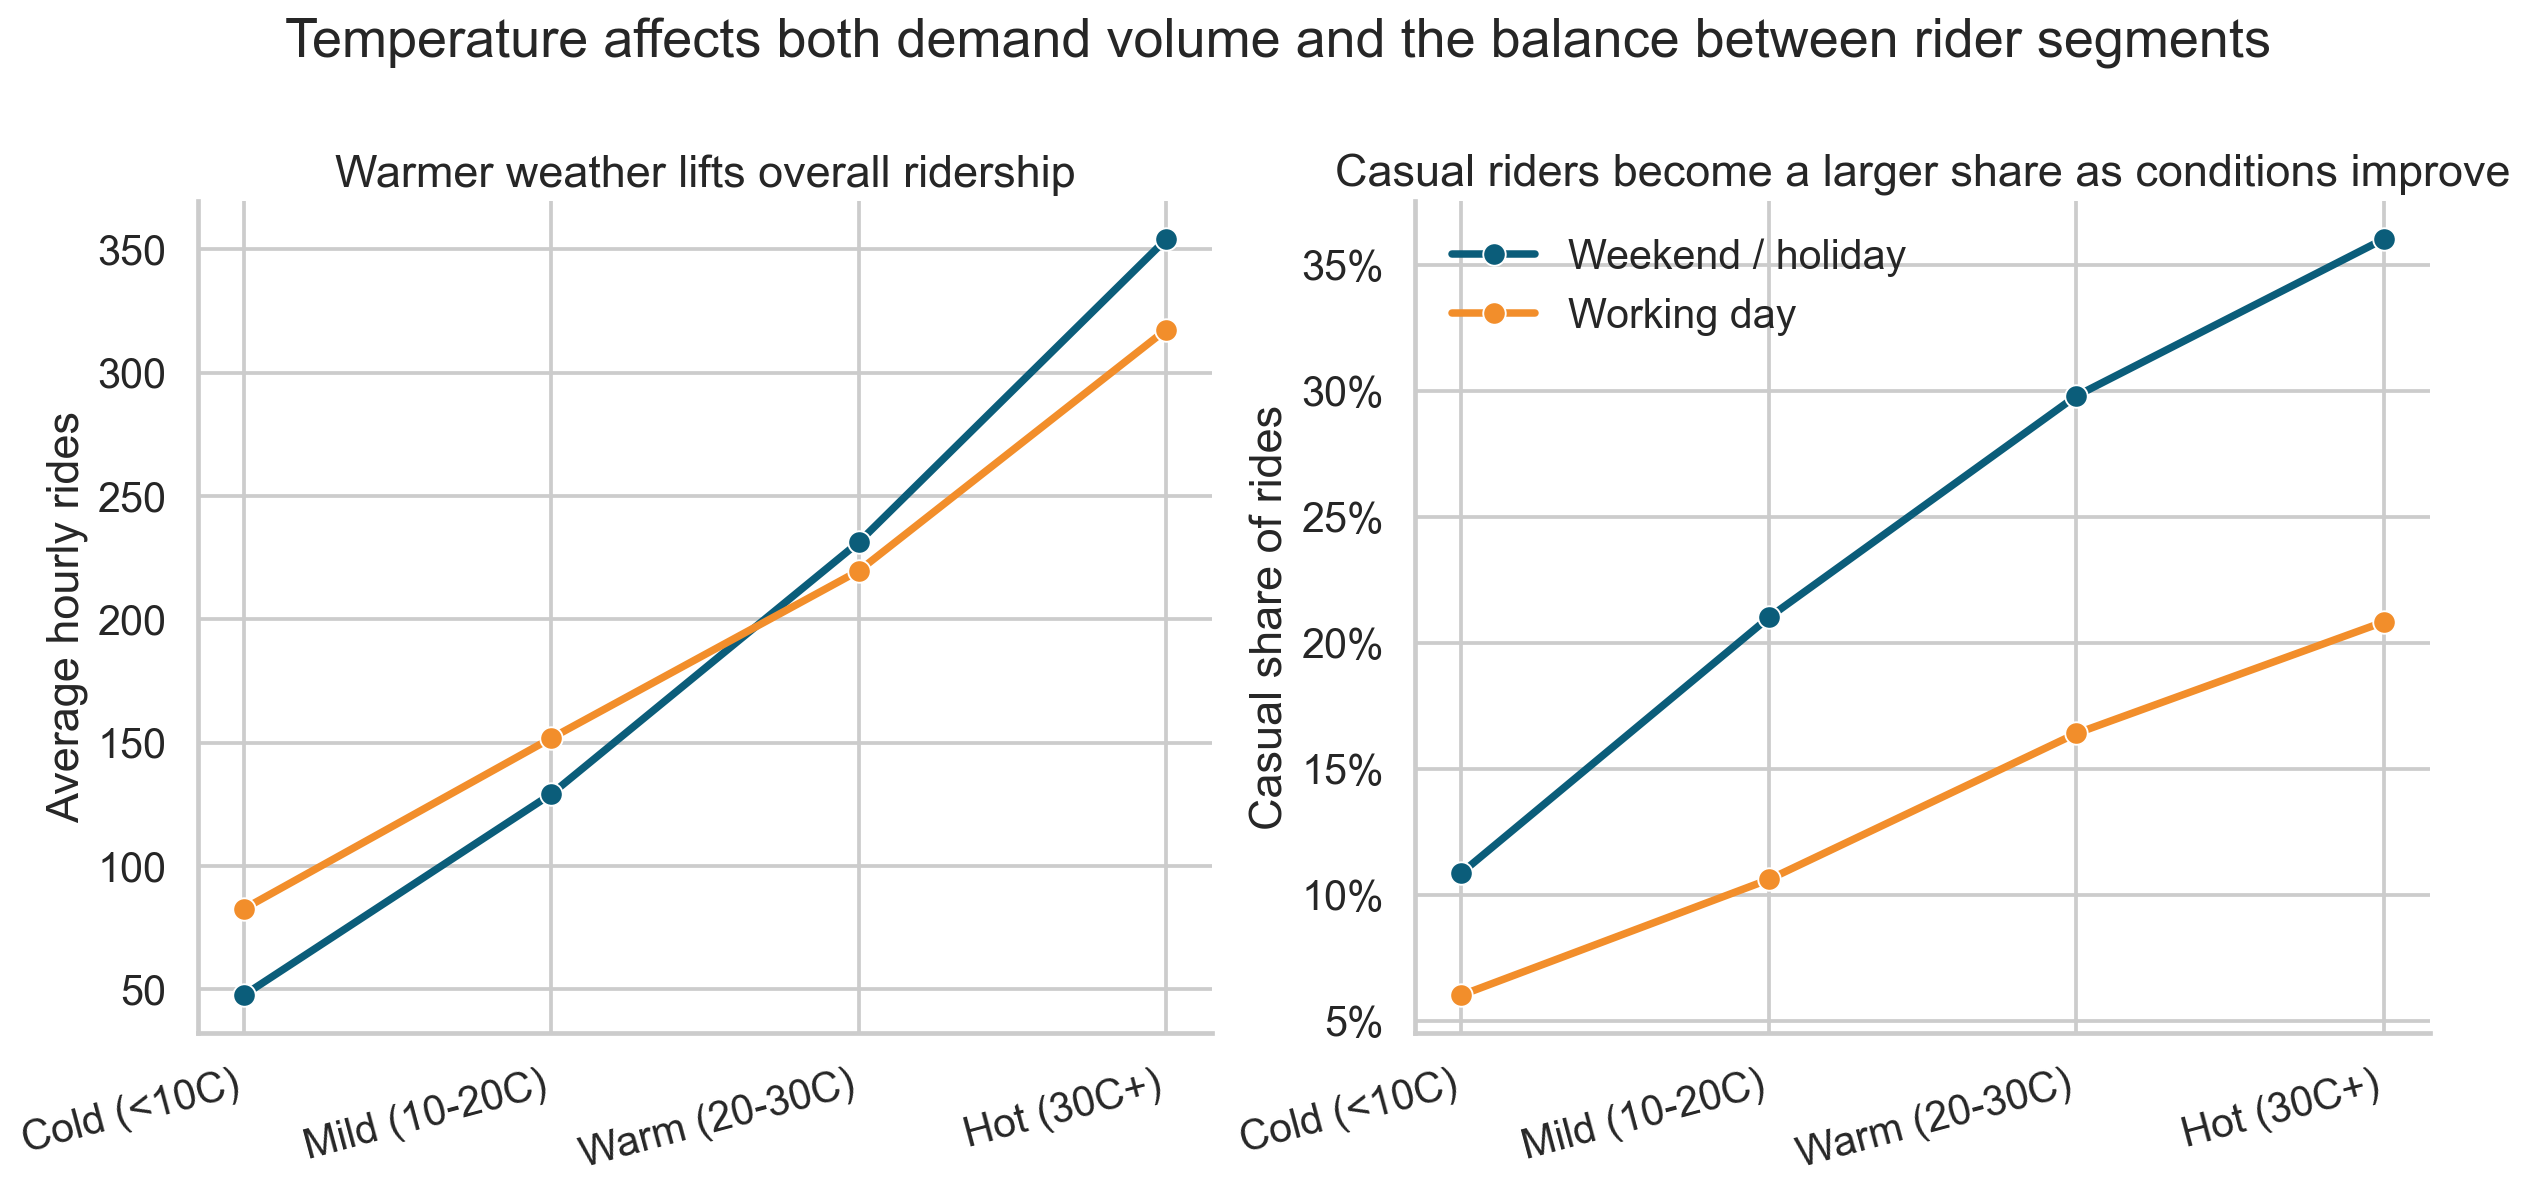

In [10]:
display(Image(filename=str(FIGURE_DIR / "06_temperature_mix.png")))

### e. Key Observations

- Demand is strongly shaped by time-of-day and day type, with weekday commute windows driving the biggest peaks.
- Registered riders dominate the system overall and are especially concentrated on working-day rush hours.
- Casual riders make up a larger share of demand on weekends, holidays, and warm days.
- Ridership drops meaningfully under precipitation, which makes weather a practical planning signal.
- The 2012 period shows materially higher demand than 2011, indicating system growth over time.


## 6. Feature Engineering

To support cleaner analysis and more useful forecasting, I created a small set of practical features:

- **rush-hour and commute-window flags** to capture predictable work-trip peaks
- **day-type labels** to separate working days from weekends and holidays
- **temperature and weather groupings** to simplify nonlinear weather effects
- **cyclical encodings for hour and month** to model repeating time patterns without artificial breaks
- **interpretable unit conversions** such as temperature in Celsius and humidity as a percentage

These features are meant to improve clarity and predictive usefulness, not add complexity for its own sake.


In [11]:
features

,feature,type,why_it_matters
0,season_label,Season category,Captures broad annual seasonality
1,weather_group,Collapsed weather severity,"Separates clear, cloudy, and precipitation con..."
2,day_type,Working day vs weekend / holiday,Distinguishes commute demand from leisure demand
3,hour_band,Grouped hour buckets,Improves readability for stakeholder summaries
4,temp_band,Grouped temperature levels,Captures nonlinear weather comfort effects
5,hour_sin / hour_cos,Cyclical hour encoding,Preserves circular nature of time-of-day
6,month_sin / month_cos,Cyclical month encoding,Preserves seasonality without artificial jumps
7,is_rush_hour,AM / PM commute indicator,Highlights peak commuting windows
8,is_commute_window,Broader commute proxy,Captures surrounding shoulder periods
9,feels_temp_gap,atemp - temp,Proxy for perceived vs measured conditions


## 7. Modeling

### a. Problem Setup

The primary prediction task is **hourly total ridership (`cnt`)**, with supporting models for casual and registered demand. Total ridership is the most useful operational target because it connects directly to availability, rebalancing, and staffing decisions.

### b. Models Used

- **Baseline mean** as a simple benchmark
- **Linear regression** and **ridge regression** as transparent baselines
- **Random forest** and **histogram gradient boosting** as stronger nonlinear models

### c. Training Approach

- chronological train/test split to avoid leakage
- training period: January 2011 to September 2012
- test period: October 2012 to December 2012
- features: calendar, weather, and engineered time-pattern variables


## 8. Model Evaluation

Model performance is compared on the held-out test set using **MAE**, **RMSE**, and **R²**. The goal is not just to find the lowest error, but to understand whether the forecast is useful enough to support planning decisions.


In [12]:
metrics_view = metrics.copy()
metrics_view[['MAE', 'RMSE', 'R2']] = metrics_view[['MAE', 'RMSE', 'R2']].round(3)
metrics_view

,target,model,MAE,RMSE,R2
0,casual,Histogram gradient boosting,9.793,17.883,0.863
1,casual,Random forest,10.640,20.049,0.827
2,casual,Ridge regression,21.671,33.452,0.519
3,casual,Linear regression,21.673,33.452,0.519
4,casual,Baseline mean,32.605,48.442,-0.009
5,cnt,Histogram gradient boosting,40.562,65.347,0.895
6,cnt,Random forest,46.310,70.833,0.877
7,cnt,Linear regression,97.404,130.326,0.582
8,cnt,Ridge regression,97.400,130.328,0.582
9,cnt,Baseline mean,156.868,204.428,-0.028


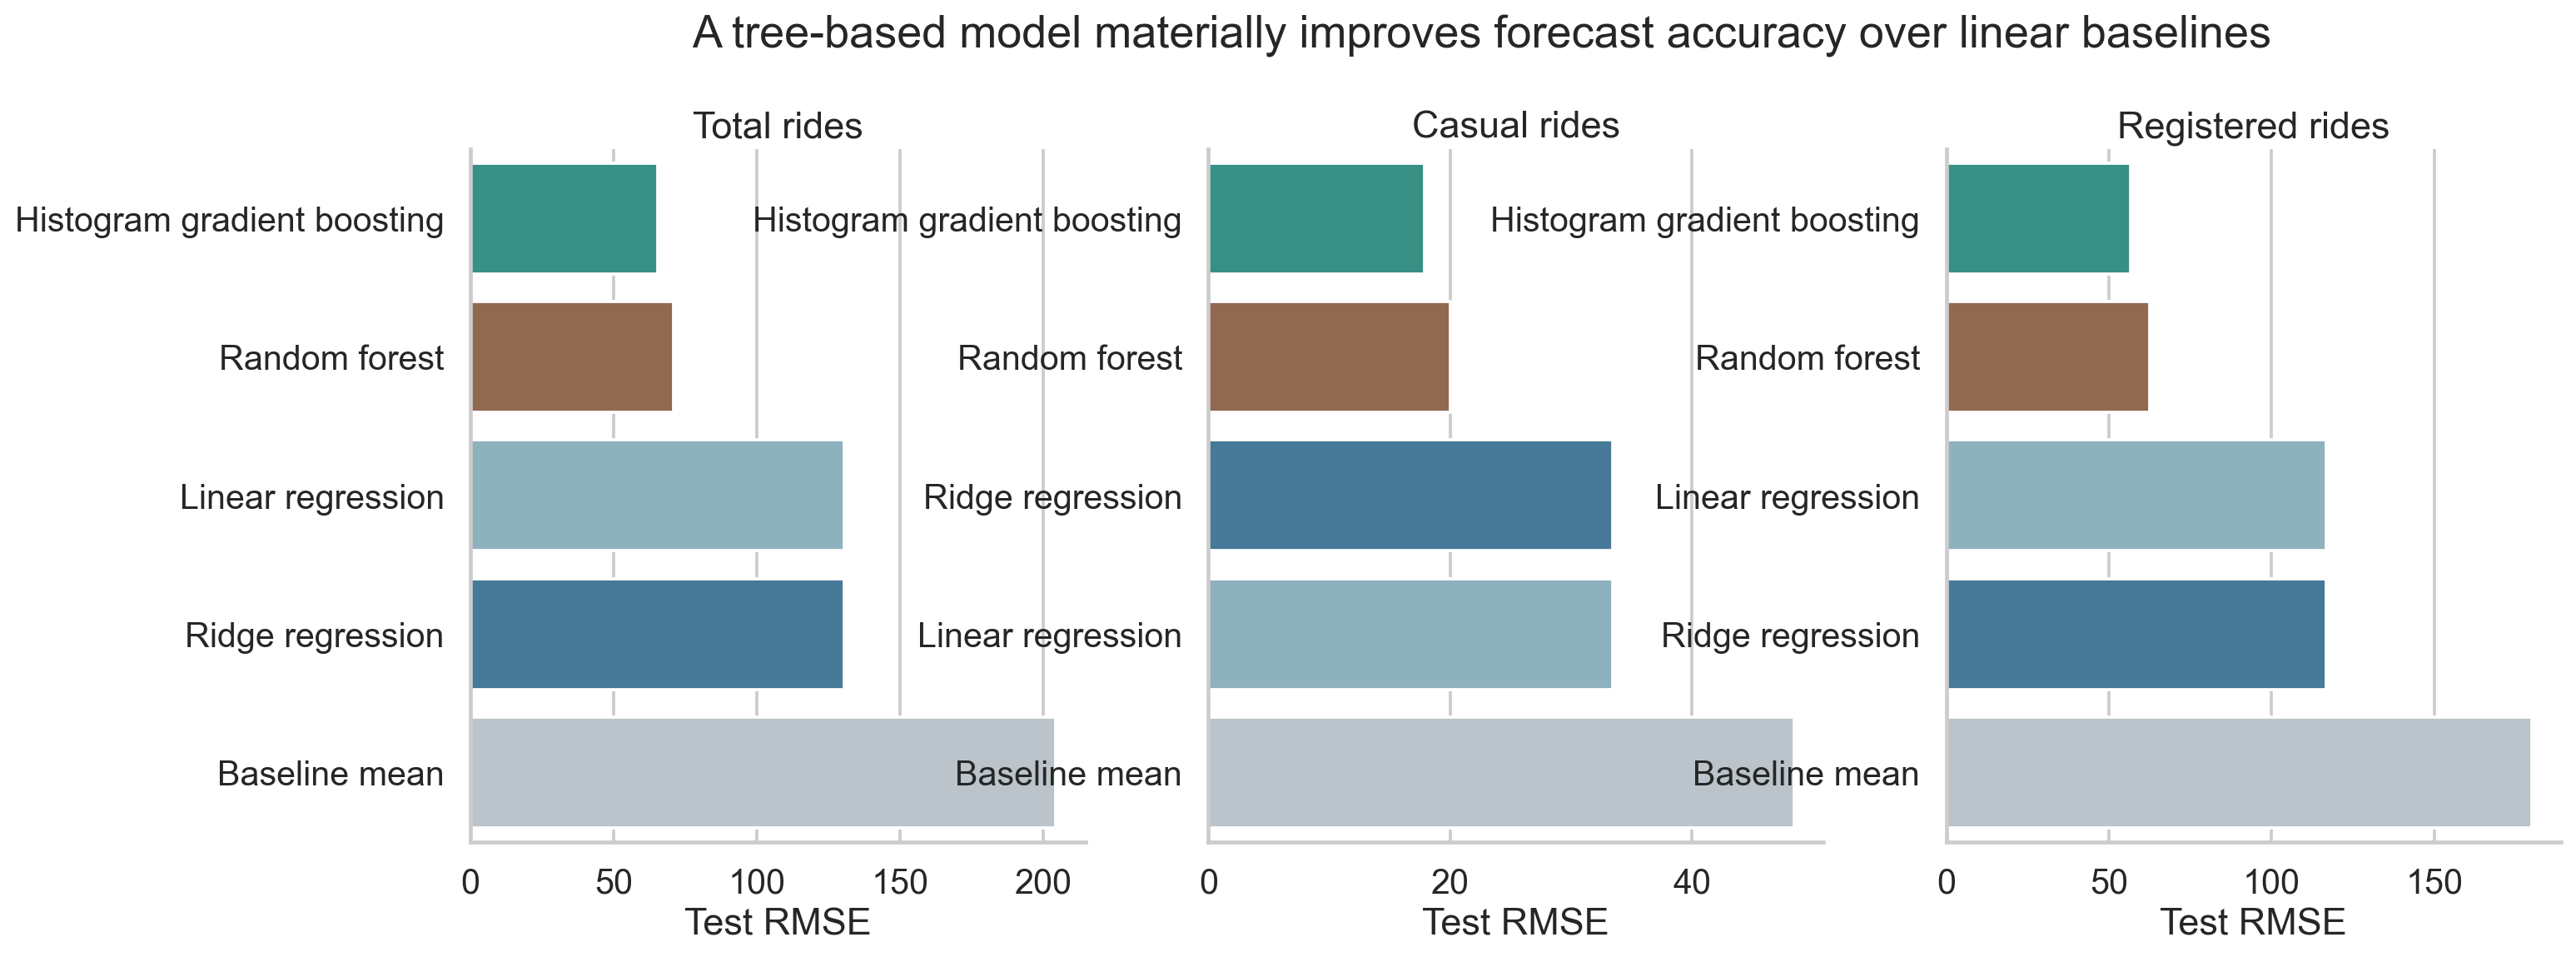

In [13]:
display(Image(filename=str(FIGURE_DIR / "07_model_comparison.png")))

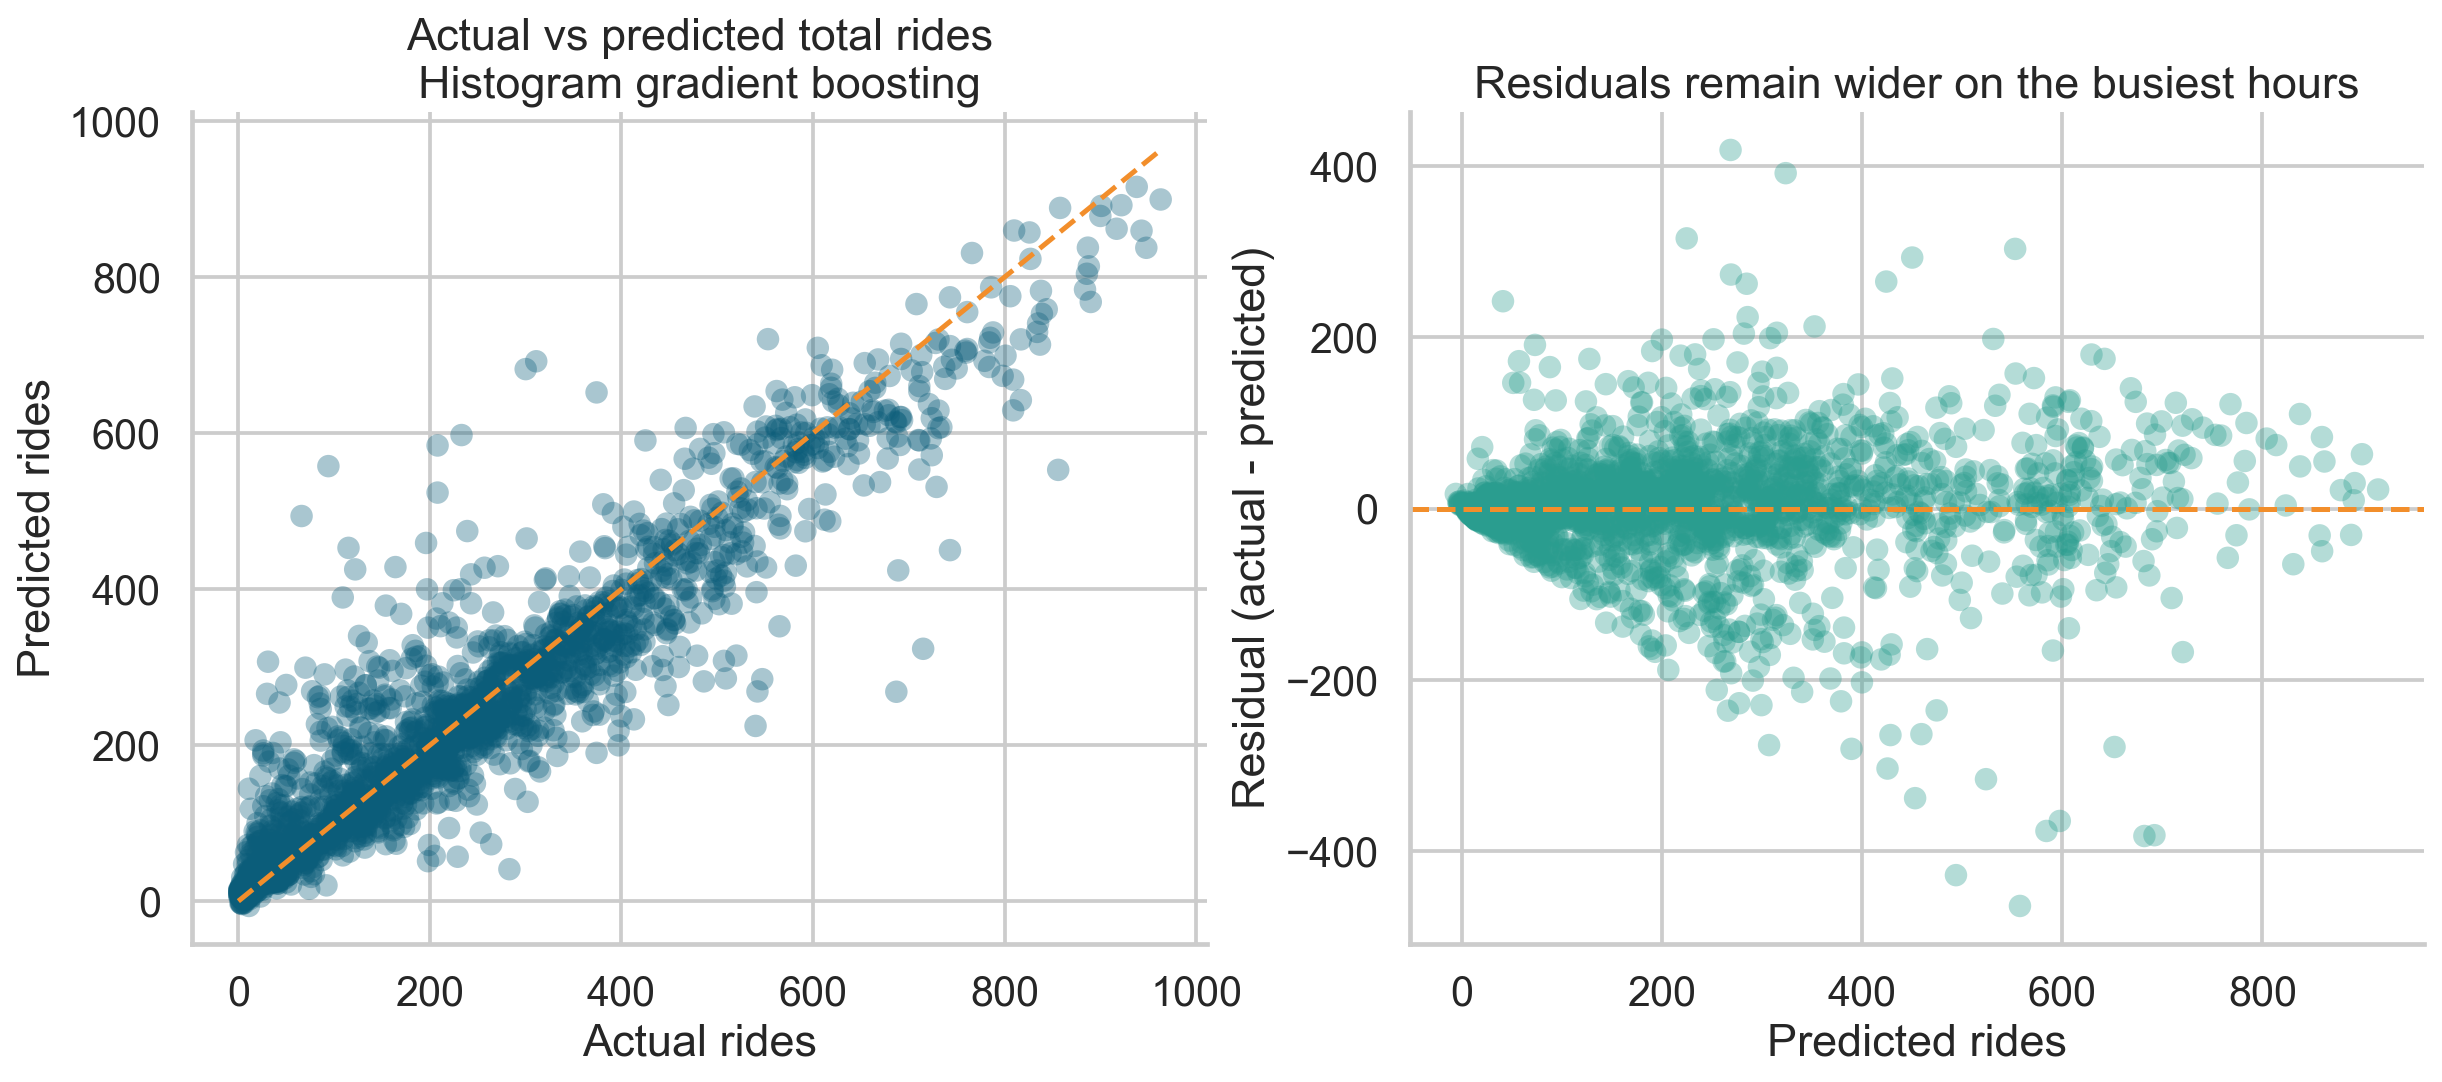

In [14]:
display(Image(filename=str(FIGURE_DIR / "08_actual_vs_predicted_total_rides.png")))

### What does this performance mean in practice?

The tree-based models substantially outperform the linear baselines, which suggests that hourly demand is driven by nonlinear interactions between time, weather, and trip purpose. In practice, the best model is accurate enough to support directional operational planning, but it still struggles on the busiest hours where demand spikes are hardest to predict.


## 9. Key Insights

- Registered riders show a strong commuting pattern, with the largest peaks on weekday rush hours.
- Casual riders are more weather-sensitive and become a much larger share of demand on warm weekends and holidays.
- Time-of-day is the strongest single driver of demand, but weather meaningfully shifts both volume and rider mix.
- Ridership is substantially lower during precipitation, making weather severity useful for short-term planning.
- Demand grew noticeably from 2011 to 2012, suggesting adoption and system maturity increased during the study period.
- A nonlinear boosting model provides a practical forecasting improvement over simple baselines, especially for total ridership.


## 10. Limitations

- The dataset is observational, so this analysis does not support causal claims.
- There are no rider demographics, so differences by age, income, or other user characteristics cannot be evaluated.
- There is no station-level geographic detail in this project’s main workflow, limiting spatial and equity analysis.
- External factors such as special events, transit disruptions, and tourism are not included, which likely explains some forecast error.


## 11. Next Steps

- Extend the work to **station-level modeling** for rebalancing and local demand planning.
- Add **real-time or forecast weather inputs** for more operationally useful predictions.
- Enrich the data with **events, transit service, and neighborhood context** to better explain peak demand shifts.
- Explore a dashboard or lightweight reporting layer so planners can use the analysis more directly.
